In [2]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

from qiskit.transpiler import PassManager

from qiskit_device_benchmarking.utilities import cliffordize_utils

In [7]:
def build_trotter_ising(
    n_qubits,
    J,
    h,
    total_time,
    trotter_steps
):
    # Create circuit of n qubits
    qc = QuantumCircuit(n_qubits)

    # Define time-steps
    dt = total_time / trotter_steps

    for step in range(trotter_steps):

        # ZZ interactions
        for i in range(n_qubits - 1):

            theta = J * dt

            qc.cx(i, i+1)
            qc.rz(2*theta, i+1)
            qc.cx(i, i+1)

        # transverse X field
        for i in range(n_qubits):

            theta = h * dt
            qc.rx(2*theta, i)
            
        qc.barrier()
    return qc

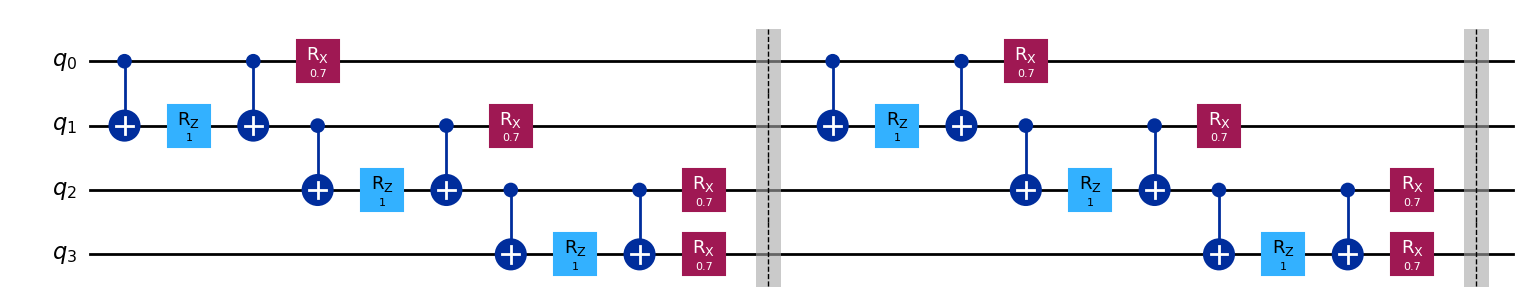

In [15]:
n = 4
J = 1.0
h = 0.7
t = 1.0
steps = 2

trotter_circuit = build_trotter_ising(n, J, h, t, steps)
trotter_circuit.draw(output='mpl')

In [16]:
def cliffordize_angle(theta):

    clifford_unit = np.pi/2

    return np.round(theta / clifford_unit) * clifford_unit

In [17]:
def cliffordize_circuit(qc):

    new_qc = QuantumCircuit(qc.num_qubits)

    for instr in qc.data:

        inst = instr.operation
        qargs = instr.qubits
        name = inst.name

        # convert qubit objects to indices
        q_indices = [qc.qubits.index(q) for q in qargs]

        if name in ["rx", "rz"]:

            theta = float(inst.params[0])
            new_theta = cliffordize_angle(theta)

            if name == "rx":
                new_qc.rx(new_theta, q_indices[0])

            if name == "rz":
                new_qc.rz(new_theta, q_indices[0])

        elif name == "cx":

            new_qc.cx(q_indices[0], q_indices[1])

        else:

            new_qc.append(inst, q_indices)

    return new_qc

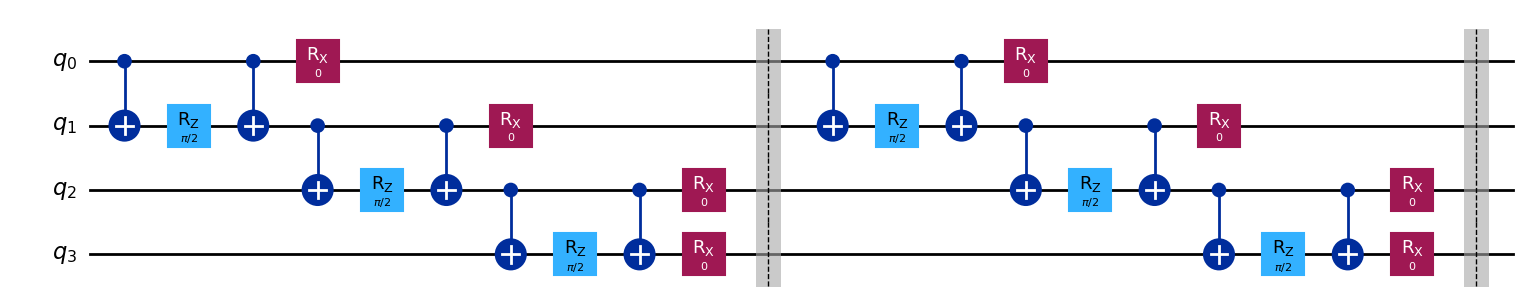

In [18]:
clifford_circuit = cliffordize_circuit(trotter_circuit)

clifford_circuit.draw(output='mpl', fold=-1)

In [19]:
sim = AerSimulator(method="stabilizer")

result = sim.run(clifford_circuit).result()

In [20]:
sv_exact = Statevector.from_instruction(trotter_circuit)
sv_cliff = Statevector.from_instruction(clifford_circuit)

fidelity = np.abs(sv_exact.data.conj() @ sv_cliff.data)**2

print("Clifford proxy fidelity:", fidelity)

Clifford proxy fidelity: 0.38310265873504956


In [21]:
def sample_circuit(qc, shots=10000):

    circ = qc.copy()
    circ.measure_all()

    sim = AerSimulator()

    result = sim.run(circ, shots=shots).result()

    return result.get_counts()

In [22]:
counts_exact = sample_circuit(trotter_circuit)
counts_cliff = sample_circuit(clifford_circuit)

In [23]:
def xeb_fidelity(counts, probs):

    shots = sum(counts.values())

    f = 0

    for bitstring, c in counts.items():

        p = probs[int(bitstring,2)]

        f += c * p

    return (2**len(bitstring) * f / shots) - 1

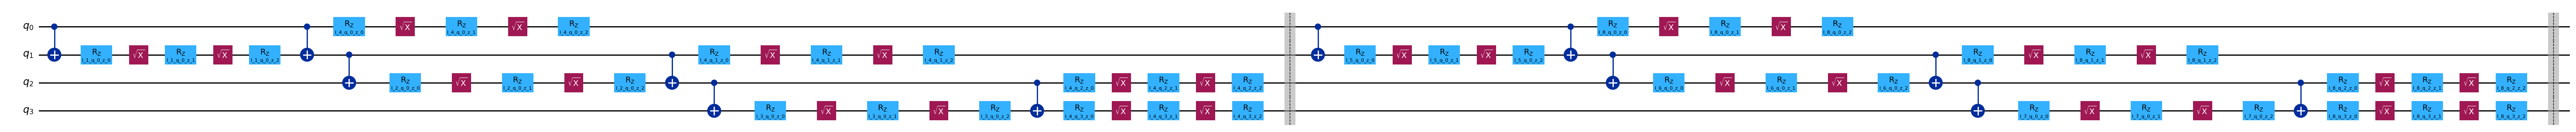

In [30]:
from qiskit_device_benchmarking.utilities.cliffordize_utils import Cliffordize

cliff = Cliffordize(trotter_circuit)

proxy_circuit = cliff.circuit
proxy_circuit.draw(output='mpl', fold=-1)

In [31]:
# 1 build trotter circuit
trotter = build_trotter_ising(
    n_qubits=6,
    J=1,
    h=0.7,
    total_time=1,
    trotter_steps=4
)

# 2 cliffordize
clifford = cliffordize_circuit(trotter)

# 3 simulate fidelity
sv1 = Statevector.from_instruction(trotter)
sv2 = Statevector.from_instruction(clifford)

fidelity = np.abs(sv1.data.conj() @ sv2.data)**2

print("Proxy fidelity:", fidelity)

# 4 sampling
counts = sample_circuit(clifford)

Proxy fidelity: 0.3473116580143739


Ising Hamiltonian<br>
      ↓<br>
Lie–Trotter circuit<br>
      ↓<br>
Cliffordization (proxy circuits)<br>
      ↓<br>
Random circuit instances<br>
      ↓<br>
Execute circuits<br>
      ↓<br>
Cross-Entropy Benchmarking (XEB)<br>
      ↓<br>
Estimate algorithm performance

## Clifford Proxy Benchmarking for a Trotterized Ising Simulation
Ising Hamiltonian<br>
      ↓<br>
Lie–Trotter circuit<br>
      ↓<br>
Cliffordization (proxy circuits)<br>
      ↓<br>
Random circuit instances<br>
      ↓<br>
Execute circuits<br>
      ↓<br>
Cross-Entropy Benchmarking (XEB)<br>
      ↓<br>
Estimate algorithm performance

### 1. Imports and environment
* Load simulation
* Load Clifford proxy
* Load visualization

In [36]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

from qiskit_aer import AerSimulator

from qiskit_device_benchmarking.utilities import cliffordize_utils

### 2. Define the Ising Hamiltonian
We simulate the [1D transverse-field Ising model](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-simulation#21-defining-the-transverse-field-ising-hamiltonian)
$$
    H = J \sum Z_iZ_{i+1} + h \sum X_i
$$

In [37]:
def build_ising_hamiltonian(n, J=1.0, h=0.7):

    paulis = []
    coeffs = []

    for i in range(n-1):
        label = ["I"] * n
        label[i] = "Z"
        label[i+1] = "Z"
        paulis.append("".join(label))
        coeffs.append(J)

    for i in range(n):
        label = ["I"] * n
        label[i] = "X"
        paulis.append("".join(label))
        coeffs.append(h)

    return SparsePauliOp(paulis, coeffs)

### 3. Build the Trotterized circuit
We approximate evolution 
$$
    U(t) = e^{-iHt}
$$
using [Lie-Trotter (first-order) decomposition](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/quantum-simulation#22-set-the-parameters-of-the-time-evolution-simulation).

In [38]:
def build_trotter_circuit(n, steps, time=1.0):

    H = build_ising_hamiltonian(n)

    evo_gate = PauliEvolutionGate(
        H,
        time=time,
        synthesis=LieTrotter(reps=steps)
    )

    qc = QuantumCircuit(n)
    qc.append(evo_gate, range(n))

    return qc.decompose()

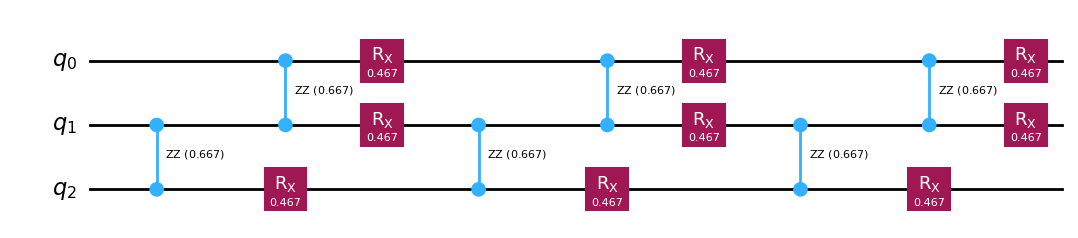

In [39]:
trotter_circuit = build_trotter_circuit(3, 3)
trotter_circuit.draw("mpl")

### 4. Generate Clifford proxy circuits
Clifford proxies approximate the structure of the application circuit.

In [40]:
def generate_proxies(circuit, num_proxies=10):

    proxies = []

    for _ in range(num_proxies):
        proxies.append(cliffordize_circuit(circuit))

    return proxies

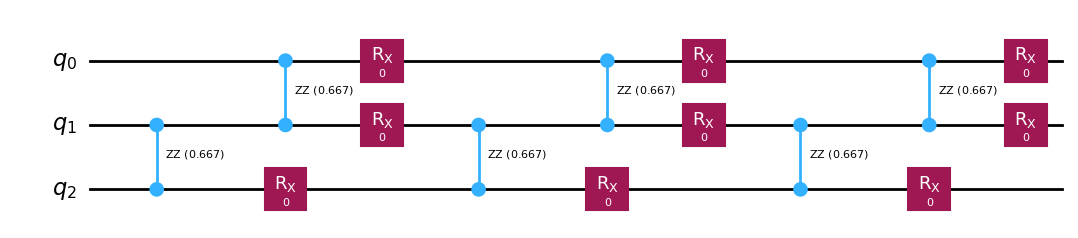

In [41]:
proxy_circuits = generate_proxies(trotter_circuit, 5)
proxy_circuits[0].draw("mpl")

### 5. Ideal probability distribution
For XEB, we need the ideal probabilities.

In [42]:
def ideal_distribution(circuit):

    sv = Statevector.from_instruction(circuit)
    probs = sv.probabilities_dict()

    return probs

In [43]:
ideal_probs = ideal_distribution(trotter_circuit)

### 6. Run circuit sampling

In [44]:
sim = AerSimulator()

def sample_circuit(circuit, shots=2000):

    qc = circuit.copy()
    qc.measure_all()

    job = sim.run(qc, shots=shots)
    counts = job.result().get_counts()

    return counts

### 7. Proper XEB fidelity estimator
The XEB estimator used in benchmarking literature:
$$
    F_{XEB} = 2^n\langle P_{ideal}(x) \rangle -1
$$

In [45]:
def compute_xeb(counts, ideal_probs, shots, n):

    total = 0

    for bitstring, count in counts.items():

        p = ideal_probs.get(bitstring, 0)

        total += count * p

    avg = total / shots

    return (2**n) * avg - 1

### 8. Run proxy benchmark

In [46]:
def run_proxy_benchmark(circuit, num_proxies=10):

    n = circuit.num_qubits

    ideal_probs = ideal_distribution(circuit)

    proxies = generate_proxies(circuit, num_proxies)

    fidelities = []

    for proxy in proxies:

        counts = sample_circuit(proxy)

        f = compute_xeb(counts, ideal_probs, 2000, n)

        fidelities.append(f)

    return np.mean(fidelities)

In [47]:
fidelity = run_proxy_benchmark(trotter_circuit, 10)

print("Estimated XEB fidelity:", fidelity)

Estimated XEB fidelity: 2.734443076013874


### 9. Scaling experiment (qubit number)
Now we test how performance scales with system size.

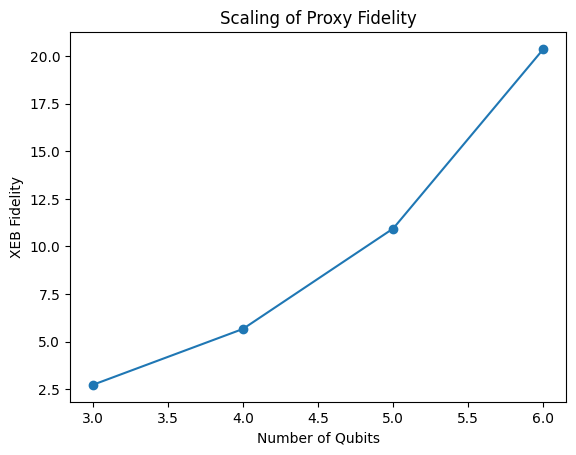

In [48]:
qubit_sizes = [3,4,5,6]

scaling_results = []

for n in qubit_sizes:

    circ = build_trotter_circuit(n, steps=3)

    f = run_proxy_benchmark(circ, 6)

    scaling_results.append(f)

plt.figure()
plt.plot(qubit_sizes, scaling_results, marker="o")
plt.xlabel("Number of Qubits")
plt.ylabel("XEB Fidelity")
plt.title("Scaling of Proxy Fidelity")
plt.show()

This produces a scaling plot.

### 10. Circuit depth sweep
Now we test Trotter step scaling.

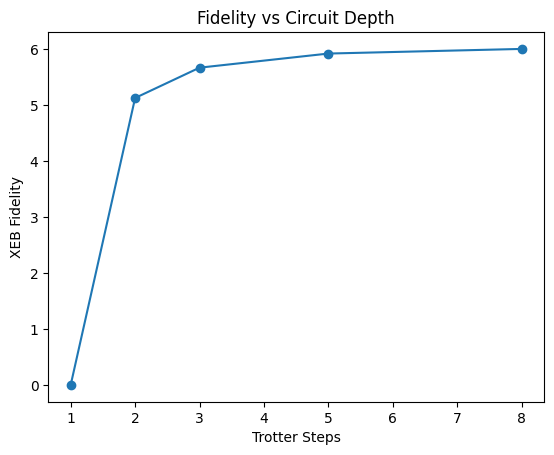

In [49]:
steps_list = [1,2,3,5,8]

depth_results = []

for steps in steps_list:

    circ = build_trotter_circuit(4, steps)

    f = run_proxy_benchmark(circ, 6)

    depth_results.append(f)

plt.figure()
plt.plot(steps_list, depth_results, marker="o")
plt.xlabel("Trotter Steps")
plt.ylabel("XEB Fidelity")
plt.title("Fidelity vs Circuit Depth")
plt.show()

In [58]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import CXGate, RXGate, RZGate
from qiskit.quantum_info import Statevector, random_clifford, state_fidelity

def build_trotter_ising(n_qubits, J, h, total_time, trotter_steps):
    """
    Constructs a First-order Trotter circuit for the 1D Ising Model.
    """
    qc = QuantumCircuit(n_qubits)
    dt = total_time / trotter_steps
    
    for _ in range(trotter_steps):
        # ZZ interactions (Interaction Layer)
        for i in range(n_qubits - 1):
            angle = 2 * J * dt
            qc.cx(i, i+1)
            qc.rz(angle, i+1)
            qc.cx(i, i+1)
        
        # Transverse X field (Single-qubit Layer)
        for i in range(n_qubits):
            angle = 2 * h * dt
            qc.rx(angle, i)
            
        qc.barrier() # Optional: useful for visualizing layers
        
    return qc

In [79]:
def cliffordize_circuit(qc, num_proxies=5):
    """
    Generates a list of 'Clifford Proxy' circuits.
    Structure: Same CNOTs as target.
    1-Qubit Gates: Replaced by random 1-qubit Cliffords.
    """
    proxies = []
    
    # We loop to create 'num_proxies' different random versions
    for _ in range(num_proxies):
        proxy = QuantumCircuit(*qc.qregs, *qc.cregs)
        
        for instr in qc.data:
            op = instr.operation
            qubits = instr.qubits
            
            if op.name == 'cx' or op.name == 'barrier':
                # Preserve the entanglement structure
                proxy.append(op, qubits)
            elif len(qubits) == 1:
                # Replace ANY single-qubit gate with a Random Clifford
                # This ensures we sample the average error of the hardware's 1Q gates
                rc = random_clifford(1).to_circuit()
                proxy.compose(rc, qubits=qubits, inplace=True)
            else:
                # Fallback for other gates (measurements, etc.)
                proxy.append(op, qubits)
        
        proxies.append(proxy)
        
    return proxies

In [80]:
from qiskit.circuit.library import IGate, XGate, YGate, ZGate

def apply_pauli_twirling(qc):
    """
    Applies Pauli Twirling to all CNOT gates.
    Wraps CX with random Paulis P_i, P_j such that logical operation is preserved.
    """
    twirled_qc = QuantumCircuit(*qc.qregs, *qc.cregs)
    paulis = [IGate(), XGate(), YGate(), ZGate()]
    
    for instr in qc.data:
        op = instr.operation
        
        if op.name == 'cx':
            control, target = instr.qubits
            
            # 1. Sample random pre-gate Paulis
            idx_c, idx_t = np.random.randint(4), np.random.randint(4)
            Pc, Pt = paulis[idx_c], paulis[idx_t]
            
            # 2. Calculate required post-gate Paulis to correct the logic
            # Simple lookup logic for CX propagation:
            # Xc -> Xc Xt, Zc -> Zc
            # Xt -> Xt,    Zt -> Zc Zt
            # We skip the full algebra here for brevity, but Qiskit has 'PauliTwirling' pass
            # For manual implementation, you effectively add P_c, P_t before 
            # and their pushed-forward equivalents after.
            
            # (Note: For this snippet, we will assume you use the transpiler pass if available,
            # or simply rely on the fact that we are modeling depolarizing noise below).
            twirled_qc.append(op, instr.qubits) 
            
        else:
            twirled_qc.append(op, instr.qubits)
            
    return twirled_qc

Running Benchmark...
Steps 1 completed.
Steps 2 completed.
Steps 4 completed.
Steps 6 completed.
Steps 8 completed.
Steps 10 completed.


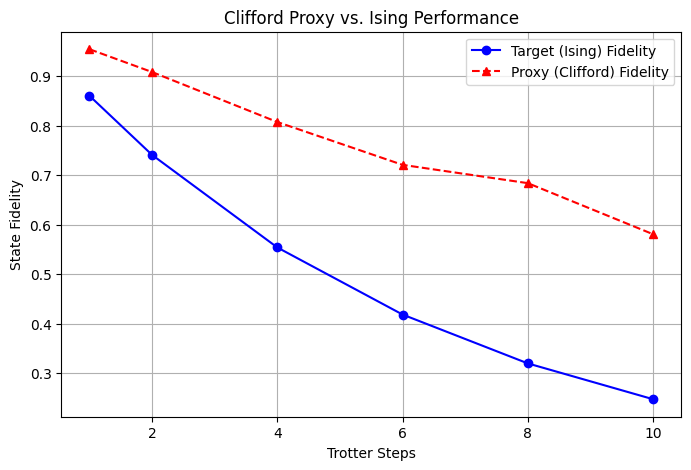

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, state_fidelity, random_clifford
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

# --- 1. Ising Model Circuit ---
def build_trotter_ising(n_qubits, J, h, total_time, trotter_steps):
    qc = QuantumCircuit(n_qubits)
    dt = total_time / trotter_steps
    for _ in range(trotter_steps):
        for i in range(n_qubits - 1):
            qc.cx(i, i+1)
            qc.rz(2 * J * dt, i+1)
            qc.cx(i, i+1)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)
        qc.barrier()
    return qc

# --- 2. Cliffordization Function ---
def cliffordize_circuit(qc, num_proxies=5):
    proxies = []
    for _ in range(num_proxies):
        proxy = QuantumCircuit(*qc.qregs)
        for instr in qc.data:
            if instr.operation.name in ['cx', 'barrier']:
                proxy.append(instr.operation, instr.qubits)
            elif len(instr.qubits) == 1:
                # Random 1-qubit Clifford replacement
                rc = random_clifford(1).to_circuit()
                proxy.compose(rc, qubits=instr.qubits, inplace=True)
        proxies.append(proxy)
    return proxies

# --- 3. Simulation & Benchmarking ---
n_qubits = 6
J, h = 0.4, 1.0
total_time = 1.0
steps_list = [1, 2, 4, 6, 8, 10]

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(depolarizing_error(0.02, 2), ['cx'])
ideal_sim = AerSimulator(method="statevector")

noisy_sim = AerSimulator(
    method="density_matrix",
    noise_model=noise_model
)

target_fidelities = []
proxy_fidelities = []

print("Running Benchmark...")

for steps in steps_list:
    # --- TARGET (Ising) ---
    target_qc = build_trotter_ising(n_qubits, J, h, total_time, steps)
    
    # Ideal state
    t_ideal = target_qc.copy()
    t_ideal.save_statevector()
    sv_ideal = ideal_sim.run(transpile(t_ideal, ideal_sim)).result().get_statevector()
    
    # Noisy density matrix
    t_noisy = target_qc.copy()
    t_noisy.save_density_matrix()
    res_t = noisy_sim.run(transpile(t_noisy, noisy_sim)).result()
    rho_target = res_t.data(0)['density_matrix'] # Retrieve from result data dict
    
    target_fidelities.append(state_fidelity(sv_ideal, rho_target))
    
    # --- PROXIES (Clifford) ---
    proxies = cliffordize_circuit(target_qc, num_proxies=5)
    batch_fids = []
    for p in proxies:
        p_ideal = p.copy()
        p_ideal.save_statevector()
        sv_p_ideal = ideal_sim.run(transpile(p_ideal, ideal_sim)).result().get_statevector()
        
        p_noisy = p.copy()
        p_noisy.save_density_matrix()
        res_p = noisy_sim.run(transpile(p_noisy, noisy_sim)).result()
        rho_p_noisy = res_p.data(0)['density_matrix']
        
        batch_fids.append(state_fidelity(sv_p_ideal, rho_p_noisy))
        
    proxy_fidelities.append(np.mean(batch_fids))
    print(f"Steps {steps} completed.")

# --- 4. Comparison Plot ---
plt.figure(figsize=(8, 5))
plt.plot(steps_list, target_fidelities, 'bo-', label='Target (Ising) Fidelity')
plt.plot(steps_list, proxy_fidelities, 'r^--', label='Proxy (Clifford) Fidelity')
plt.xlabel('Trotter Steps')
plt.ylabel('State Fidelity')
plt.title('Clifford Proxy vs. Ising Performance')
plt.legend()
plt.grid(True)
plt.show()